In [1]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

project_id = "my-product-portfolio"
dataset = "bigquery-public-data.ga4_obfuscated_sample_ecommerce"

client = bigquery.Client(project=project_id)

client.create_dataset("ga4_analysis", exists_ok=True)
print("Dataset ready")

Dataset ready


In [2]:
query = f"""
SELECT
  event_name,
  COUNT(*) AS event_count,
  COUNT(DISTINCT user_pseudo_id) AS unique_users
FROM `{dataset}.events_*`
GROUP BY event_name
ORDER BY event_count DESC
"""

client.query(query).to_dataframe()

,event_name,event_count,unique_users
0,page_view,1350428,269792
1,user_engagement,1058721,213004
2,scroll,493072,138098
3,view_item,386068,61252
4,session_start,354970,267116
5,first_visit,257462,257314
6,view_promotion,190104,102443
7,add_to_cart,58543,12545
8,begin_checkout,38757,9715
9,select_item,31007,13180


In [3]:
query=f"""
SELECT distinct params.key FROM `{dataset}.events_*`,
UNNEST(event_params) as params
ORDER BY params.key
"""

client.query(query).to_dataframe()

,key
0,all_data
1,campaign
2,clean_event
3,coupon
4,currency
5,dclid
6,debug_mode
7,engaged_session_event
8,engagement_time_msec
9,entrances


In [4]:
query=f"""
SELECT COUNT(DISTINCT user_pseudo_id) AS usr_cnt FROM `{dataset}.events_*`
"""
client.query(query).to_dataframe()

,usr_cnt
0,270154


In [5]:
query=f"""
SELECT * FROM `{dataset}.events_*` LIMIT 5
"""
client.query(query).to_dataframe()

,event_date,event_timestamp,event_name,event_params,event_previous_timestamp,event_value_in_usd,event_bundle_sequence_id,event_server_timestamp_offset,user_id,user_pseudo_id,...,user_ltv,device,geo,app_info,traffic_source,stream_id,platform,event_dimensions,ecommerce,items
0,20210101,1609468318563156,first_visit,"[{'key': 'ga_session_number', 'value': {'strin...",<NA>,NaN,1177212143,<NA>,None,1003046.9452926974,...,"{'revenue': 0.0, 'currency': 'USD'}","{'category': 'desktop', 'mobile_brand_name': '...","{'continent': 'Europe', 'sub_continent': 'West...",None,"{'medium': 'organic', 'name': '(organic)', 'so...",2100450278,WEB,None,"{'total_item_quantity': None, 'purchase_revenu...",[]
1,20210101,1609468318563156,page_view,"[{'key': 'page_location', 'value': {'string_va...",<NA>,NaN,1177212143,<NA>,None,1003046.9452926974,...,"{'revenue': 0.0, 'currency': 'USD'}","{'category': 'desktop', 'mobile_brand_name': '...","{'continent': 'Europe', 'sub_continent': 'West...",None,"{'medium': 'organic', 'name': '(organic)', 'so...",2100450278,WEB,None,"{'total_item_quantity': None, 'purchase_revenu...",[]
2,20210101,1609468318563156,session_start,"[{'key': 'ga_session_number', 'value': {'strin...",<NA>,NaN,1177212143,<NA>,None,1003046.9452926974,...,"{'revenue': 0.0, 'currency': 'USD'}","{'category': 'desktop', 'mobile_brand_name': '...","{'continent': 'Europe', 'sub_continent': 'West...",None,"{'medium': 'organic', 'name': '(organic)', 'so...",2100450278,WEB,None,"{'total_item_quantity': None, 'purchase_revenu...",[]
3,20210101,1609468320458554,user_engagement,"[{'key': 'engaged_session_event', 'value': {'s...",<NA>,NaN,7525162155,<NA>,None,1003046.9452926974,...,"{'revenue': 0.0, 'currency': 'USD'}","{'category': 'desktop', 'mobile_brand_name': '...","{'continent': 'Europe', 'sub_continent': 'West...",None,"{'medium': 'organic', 'name': '(organic)', 'so...",2100450278,WEB,None,"{'total_item_quantity': None, 'purchase_revenu...",[]
4,20210101,1609468320458554,page_view,"[{'key': 'ga_session_id', 'value': {'string_va...",<NA>,NaN,7525162155,<NA>,None,1003046.9452926974,...,"{'revenue': 0.0, 'currency': 'USD'}","{'category': 'desktop', 'mobile_brand_name': '...","{'continent': 'Europe', 'sub_continent': 'West...",None,"{'medium': 'organic', 'name': '(organic)', 'so...",2100450278,WEB,None,"{'total_item_quantity': None, 'purchase_revenu...",[]


In [6]:
query=f"""
SELECT MIN(event_date) as min_date,
MAX(event_date) as max_date,
COUNT(DISTINCT event_date) AS unique_days_count
FROM `{dataset}.events_*`
"""
client.query(query).to_dataframe()

,min_date,max_date,unique_days_count
0,20201101,20210131,92


In [7]:
query=f"""
SELECT
  SAFE_DIVIDE(
    COUNTIF(ecommerce.purchase_revenue IS NULL),
    COUNT(*)
  ) * 100 AS null_rate_percentage
FROM `{dataset}.events_*`
"""
client.query(query).to_dataframe()

,null_rate_percentage
0,99.877968


**FUNNEL ANALYSIS**

In [8]:
create_view_query=f"""
CREATE OR REPLACE VIEW `{project_id}.ga4_analysis.funnel_base` AS

WITH user_type AS (
SELECT user_pseudo_id,
CASE WHEN MIN(params.value.int_value) = 1 THEN 'New' ELSE 'Returning' END AS user_type
FROM  `{dataset}.events_*`,
UNNEST(event_params) as params
WHERE params.key='ga_session_number'
GROUP BY user_pseudo_id
)

SELECT
  CASE
    WHEN event_name='session_start' THEN 'visited'
    WHEN event_name='view_item' THEN 'viewed_item'
    WHEN event_name='add_to_cart' THEN 'added_to_cart'
    WHEN event_name='begin_checkout' THEN 'begin_checkout'
    WHEN event_name='add_shipping_info' THEN 'added_shipping_info'
    WHEN event_name='add_payment_info' THEN 'added_payment_info'
    WHEN event_name='purchase' THEN 'purchased'
  END AS stage,
  CASE
      WHEN event_name = 'session_start'     THEN 1
      WHEN event_name = 'view_item'         THEN 2
      WHEN event_name = 'add_to_cart'       THEN 3
      WHEN event_name = 'begin_checkout'    THEN 4
      WHEN event_name = 'add_shipping_info' THEN 5
      WHEN event_name = 'add_payment_info'  THEN 6
      WHEN event_name = 'purchase'          THEN 7
 END AS step_order,
 e.user_pseudo_id,
 e.device.category,
 e.traffic_source.medium,
 e.geo.country,
 ut.user_type
 FROM `{dataset}.events_*` e
 LEFT JOIN user_type ut USING (user_pseudo_id)
 WHERE event_name IN ('session_start', 'view_item', 'add_to_cart', 'begin_checkout',
                     'add_shipping_info', 'add_payment_info', 'purchase')
"""

client.query(create_view_query).result()
print("View created successfully")

View created successfully


1.65% total conversion rate — massive overall leakage.

41% drop-off at payment — high friction in the final step.

79% loss between view_item and add_to_cart — high browse, low intent traffic.

In [9]:
query=f"""
WITH funnel_count AS (
  SELECT stage,step_order,COUNT(DISTINCT user_pseudo_id) AS users
  FROM `{project_id}.ga4_analysis.funnel_base`
  GROUP BY stage,step_order
)

SELECT stage,step_order,users,
ROUND(SAFE_DIVIDE(users,FIRST_VALUE(users) OVER(ORDER BY step_order))*100,2) as pct_of_top,
ROUND(COALESCE(SAFE_DIVIDE(LAG(users) OVER(ORDER BY step_order) - users,LAG(users) OVER(ORDER BY step_order))*100,0),2) AS dropoff_from_prev
FROM funnel_count
ORDER BY step_order
"""
df_funnel=client.query(query).to_dataframe()
df_funnel

,stage,step_order,users,pct_of_top,dropoff_from_prev
0,visited,1,267116,100.00,0.00
1,viewed_item,2,61252,22.93,77.07
2,added_to_cart,3,12545,4.70,79.52
3,begin_checkout,4,9715,3.64,22.56
4,added_shipping_info,5,9714,3.64,0.01
5,added_payment_info,6,5751,2.15,40.80
6,purchased,7,4419,1.65,23.16


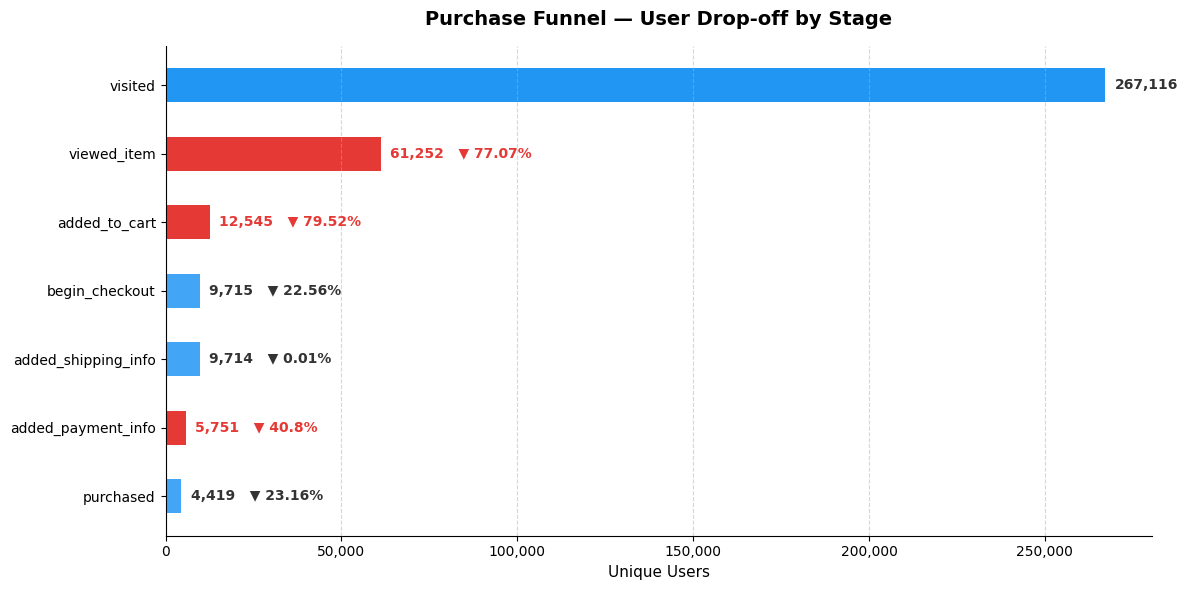

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2196F3' if i == 0 else '#E53935' if v > 40 else '#42A5F5'
          for i, v in enumerate(df_funnel['dropoff_from_prev'])]

bars = ax.barh(df_funnel['stage'], df_funnel['users'], color=colors, height=0.5)


for i, (bar, users, dropoff) in enumerate(zip(bars, df_funnel['users'], df_funnel['dropoff_from_prev'])):
    label = f'{users:,}' if i == 0 else f'{users:,}   ▼ {dropoff}%'
    color = '#E53935' if dropoff > 40 and i > 0 else '#333333'
    ax.text(bar.get_width() + max(df_funnel['users']) * 0.01,
            bar.get_y() + bar.get_height()/2,
            label, va='center', ha='left', fontsize=10,
            color=color, fontweight='bold')

ax.set_title('Purchase Funnel — User Drop-off by Stage', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Unique Users', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [11]:
query=f"""
SELECT device.category,COUNT(DISTINCT user_pseudo_id) as users
FROM `{dataset}.events_*` GROUP BY device.category
"""
client.query(query).to_dataframe()

,category,users
0,desktop,158917
1,mobile,109195
2,tablet,6250



> Funnel behavior is consistent across all devices — conversion and drop-off rates are nearly identical for desktop, mobile and tablet. Device is not a factor in the drop-off problem.



In [12]:
query=f"""
WITH funnel_count AS(
  SELECT stage,step_order,category,COUNT(DISTINCT user_pseudo_id) as users
  FROM `{project_id}.ga4_analysis.funnel_base`
  GROUP BY stage,step_order,category
)

SELECT stage,step_order,category,users,
ROUND(SAFE_DIVIDE(users,FIRST_VALUE(users) OVER(PARTITION BY category ORDER BY step_order))*100,2) as pct_of_top,
ROUND(COALESCE(SAFE_DIVIDE(LAG(users) OVER(PARTITION BY category ORDER BY step_order) - users,
LAG(users) OVER(PARTITION BY category ORDER BY step_order))*100,0),2) as dropoff_from_prev
FROM funnel_count
ORDER BY step_order
"""
client.query(query).to_dataframe()

,stage,step_order,category,users,pct_of_top,dropoff_from_prev
0,visited,1,desktop,157079,100.00,0.00
1,visited,1,mobile,107981,100.00,0.00
2,visited,1,tablet,6175,100.00,0.00
3,viewed_item,2,desktop,36323,23.12,76.88
4,viewed_item,2,mobile,24810,22.98,77.02
5,viewed_item,2,tablet,1443,23.37,76.63
6,added_to_cart,3,desktop,7384,4.70,79.67
7,added_to_cart,3,mobile,5142,4.76,79.27
8,added_to_cart,3,tablet,276,4.47,80.87
9,begin_checkout,4,desktop,5665,3.61,23.28


In [13]:
query=f"""
SELECT traffic_source.medium,traffic_source.source,COUNT(DISTINCT user_pseudo_id) as users from `{dataset}.events_*`
GROUP BY traffic_source.medium,traffic_source.source ORDER BY users DESC
"""
client.query(query).to_dataframe()

,medium,source,users
0,organic,google,103487
1,(none),(direct),75951
2,<Other>,<Other>,51037
3,referral,<Other>,32880
4,referral,shop.googlemerchandisestore.com,26065
5,(data deleted),(data deleted),17948
6,cpc,google,15527
7,organic,<Other>,10095
8,(data deleted),<Other>,393
9,referral,(data deleted),3


>Medium: referral converts best (1.89%), CPC worst (0.98%) despite being paid channel

In [14]:
query=f"""
WITH funnel_count AS (
  SELECT stage,step_order,medium,COUNT(DISTINCT user_pseudo_id) as users,
  FROM `{project_id}.ga4_analysis.funnel_base`
  WHERE medium NOT IN ('<Other>','(data deleted)')
  GROUP BY stage,step_order,medium
)

SELECT stage,step_order,medium,users,
ROUND(SAFE_DIVIDE(users,FIRST_VALUE(users) OVER(PARTITION BY medium ORDER BY step_order))*100,2) as pct_of_top,
ROUND(COALESCE(SAFE_DIVIDE(LAG(users) OVER(PARTITION BY medium ORDER BY step_order) - users,
LAG(users) OVER(PARTITION BY medium ORDER BY step_order))*100,0),2) AS dropoff_from_prev
FROM funnel_count
ORDER BY step_order
"""
client.query(query).to_dataframe()

,stage,step_order,medium,users,pct_of_top,dropoff_from_prev
0,visited,1,(none),75025,100.00,0.00
1,visited,1,cpc,15450,100.00,0.00
2,visited,1,organic,111346,100.00,0.00
3,visited,1,referral,54380,100.00,0.00
4,viewed_item,2,(none),16492,21.98,78.02
5,viewed_item,2,cpc,3156,20.43,79.57
6,viewed_item,2,organic,24077,21.62,78.38
7,viewed_item,2,referral,12730,23.41,76.59
8,added_to_cart,3,(none),3338,4.45,79.76
9,added_to_cart,3,cpc,561,3.63,82.22


>New vs Returning: returning users convert at 9.37% vs 1.39% for new — 6.7x difference

In [15]:
query=f"""
WITH funnel_count AS (
  SELECT stage,step_order,user_type,COUNT(DISTINCT user_pseudo_id) as users
  FROM `{project_id}.ga4_analysis.funnel_base`
  GROUP BY stage,step_order,user_type
)

SELECT stage,step_order,user_type,users,
ROUND(SAFE_DIVIDE(users,FIRST_VALUE(users) OVER(PARTITION BY user_type ORDER BY step_order))*100,2) as pct_of_top,
ROUND(COALESCE(SAFE_DIVIDE(LAG(users) OVER(PARTITION BY user_type ORDER BY step_order) - users,
LAG(users) OVER(PARTITION BY user_type ORDER BY step_order))*100,0),2) AS dropoff_from_prev
FROM funnel_count
ORDER BY step_order
"""
df_new_returning = client.query(query).to_dataframe()
df_new_returning

,stage,step_order,user_type,users,pct_of_top,dropoff_from_prev
0,visited,1,New,258280,100.00,0.00
1,visited,1,Returning,8836,100.00,0.00
2,viewed_item,2,New,57113,22.11,77.89
3,viewed_item,2,Returning,4139,46.84,53.16
4,added_to_cart,3,New,11512,4.46,79.84
5,added_to_cart,3,Returning,1033,11.69,75.04
6,begin_checkout,4,New,8526,3.30,25.94
7,begin_checkout,4,Returning,1189,13.46,-15.10
8,added_shipping_info,5,New,8525,3.30,0.01
9,added_shipping_info,5,Returning,1189,13.46,0.00


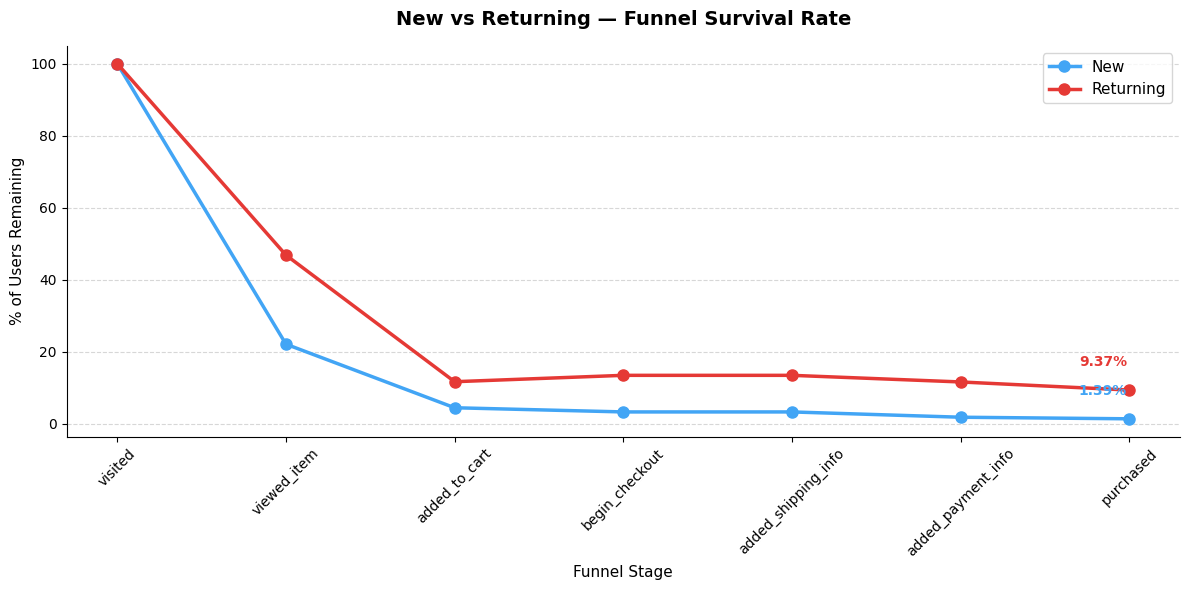

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

new_users = df_new_returning[df_new_returning['user_type'] == 'New']
returning_users = df_new_returning[df_new_returning['user_type'] == 'Returning']

ax.plot(new_users['stage'], new_users['pct_of_top'],
        marker='o', linewidth=2.5, markersize=8, color='#42A5F5', label='New')
ax.plot(returning_users['stage'], returning_users['pct_of_top'],
        marker='o', linewidth=2.5, markersize=8, color='#E53935', label='Returning')

ax.annotate('1.39%', xy=(6, new_users['pct_of_top'].iloc[-1]),
            xytext=(5.7, 8), color='#42A5F5', fontweight='bold', fontsize=10)
ax.annotate('9.37%', xy=(6, returning_users['pct_of_top'].iloc[-1]),
            xytext=(5.7, 16), color='#E53935', fontweight='bold', fontsize=10)

ax.set_title('New vs Returning — Funnel Survival Rate', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Funnel Stage', fontsize=11)
ax.set_ylabel('% of Users Remaining', fontsize=11)
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [17]:
query = f"""
SELECT country, COUNT(DISTINCT user_pseudo_id) AS users
FROM `{project_id}.ga4_analysis.funnel_base`
WHERE stage = 'purchased'
GROUP BY country
ORDER BY users DESC
LIMIT 10
"""
client.query(query).to_dataframe()

,country,users
0,United States,1942
1,India,406
2,Canada,355
3,United Kingdom,137
4,France,93
5,Spain,84
6,Germany,74
7,Taiwan,72
8,Japan,68
9,China,68


In [18]:
query=f"""
WITH funnel_count AS (
SELECT stage,step_order,country,COUNT(DISTINCT user_pseudo_id) as users
FROM `{project_id}.ga4_analysis.funnel_base`
WHERE country IN ('United States','India','Canada','United Kingdom',
                  'France','Spain','Germany','Taiwan','China','Japan')
GROUP BY stage,step_order,country
)
SELECT stage,step_order,country,users,
ROUND(SAFE_DIVIDE(users,FIRST_VALUE(users) OVER(PARTITION BY country ORDER BY step_order))*100,2) AS pct_of_top,
ROUND(COALESCE(SAFE_DIVIDE(LAG(users) OVER(PARTITION BY country ORDER BY step_order) - users,
LAG(users) OVER(PARTITION BY country ORDER BY step_order))*100,0),2) AS dropoff_from_prev
FROM funnel_count
ORDER BY step_order
"""
df_funnel_country = client.query(query).to_dataframe()
df_funnel_country

,stage,step_order,country,users,pct_of_top,dropoff_from_prev
0,visited,1,Canada,20037,100.00,0.00
1,visited,1,China,4564,100.00,0.00
2,visited,1,France,5322,100.00,0.00
3,visited,1,Germany,4813,100.00,0.00
4,visited,1,India,25059,100.00,0.00
...,...,...,...,...,...,...
65,purchased,7,Japan,68,1.93,17.07
66,purchased,7,Spain,84,1.68,22.22
67,purchased,7,Taiwan,72,1.59,26.53
68,purchased,7,United Kingdom,137,1.63,19.41


 >Geo: conversion consistent across all top 10 countries (1.49%–1.93%) — drop-off is a site-wide issue not region specific

In [19]:
query = f"""
WITH funnel_count AS (
  SELECT stage, step_order, country, COUNT(DISTINCT user_pseudo_id) AS users
  FROM `{project_id}.ga4_analysis.funnel_base`
  WHERE country IN ('United States','India','Canada','United Kingdom',
                    'France','Spain','Germany','Taiwan','China','Japan')
  GROUP BY stage, step_order, country
),

funnel_with_pct AS (
SELECT stage, step_order, country, users,
  ROUND(SAFE_DIVIDE(users, FIRST_VALUE(users) OVER(PARTITION BY country ORDER BY step_order))*100,2) AS pct_of_top
FROM funnel_count
)

SELECT country, users, pct_of_top AS conversion_rate
FROM funnel_with_pct
WHERE stage = 'purchased'
ORDER BY conversion_rate DESC
"""

client.query(query).to_dataframe()

,country,users,conversion_rate
0,Japan,68,1.93
1,Canada,355,1.77
2,France,93,1.75
3,Spain,84,1.68
4,United States,1942,1.66
5,United Kingdom,137,1.63
6,India,406,1.62
7,Taiwan,72,1.59
8,Germany,74,1.54
9,China,68,1.49


**SESSION ANALYSIS**

In [20]:
query=f"""
SELECT
  COUNT(*) AS total_events,
  COUNTIF((SELECT key FROM UNNEST(event_params) WHERE key = 'ga_session_id') IS NOT NULL) AS has_id,
  COUNTIF((SELECT key FROM UNNEST(event_params) WHERE key = 'ga_session_number') IS NOT NULL) AS has_number,
  COUNTIF(
    (SELECT key FROM UNNEST(event_params) WHERE key = 'ga_session_id') IS NOT NULL
    AND (SELECT key FROM UNNEST(event_params) WHERE key = 'ga_session_number') IS NOT NULL
  ) AS has_both
FROM `{dataset}.events_*`
"""
client.query(query).to_dataframe()

,total_events,has_id,has_number,has_both
0,4295584,4295584,4295584,4295584


In [21]:
query = f"""
SELECT
  COUNT(DISTINCT user_pseudo_id) AS users_without_session_id
FROM `{dataset}.events_*`
WHERE user_pseudo_id NOT IN (
  SELECT DISTINCT user_pseudo_id
  FROM `{dataset}.events_*`,
  UNNEST(event_params) AS ep
  WHERE ep.key = 'ga_session_id'
)
"""
client.query(query).to_dataframe()

,users_without_session_id
0,0


>Only 1.35% of sessions convert to purchase, with 11% never engaging at all — pointing to a significant low-intent traffic problem

In [22]:
query=f"""
WITH session AS(
  SELECT user_pseudo_id,
    (SELECT ep.value.int_value FROM UNNEST(event_params) AS ep WHERE ep.key='ga_session_id') AS session_id,
    (SELECT ep.value.int_value FROM UNNEST(event_params) AS ep WHERE ep.key='ga_session_number') AS session_number,
    TIMESTAMP_MICROS(MIN(event_timestamp)) AS start_time,
    TIMESTAMP_DIFF(TIMESTAMP_MICROS(MAX(event_timestamp)),TIMESTAMP_MICROS(MIN(event_timestamp)),SECOND) AS duration,
    COUNTIF(event_name='page_view') AS page_visited,
    MAX(COALESCE(
      (SELECT value.int_value FROM UNNEST(event_params) WHERE key='session_engaged'),
      SAFE_CAST((SELECT value.string_value FROM UNNEST(event_params) WHERE key='session_engaged')
      AS INT64)
    )) AS is_engaged,
    MAX(CASE WHEN event_name='purchase' THEN 1 ELSE 0 END) AS did_purchase
  FROM `{dataset}.events_*`
  GROUP BY user_pseudo_id, session_id,session_number
)

SELECT
  COUNT(session_id) as total_sessions,
  ROUND(AVG(duration) / 60,2) as avg_duration,
  ROUND(AVG(page_visited),2) AS avgpage_per_session,
  ROUND(COUNTIF(is_engaged IS NULL OR is_engaged=0) /COUNT(*) * 100,2) AS bounce_rate,
  ROUND(SUM(did_purchase) / COUNT(*) * 100,2) AS purchase_rate
FROM session
"""
client.query(query).to_dataframe()

,total_sessions,avg_duration,avgpage_per_session,bounce_rate,purchase_rate
0,360129,3.38,3.75,11.12,1.35


>Purchasing sessions last 7.7x longer (23.83 vs 3.10 mins) and visit 9x more pages (30.95 vs 3.38) — buyers are a fundamentally different type of visitor, not just lucky conversions

In [23]:
query=f"""
WITH session AS(
  SELECT user_pseudo_id,
    (SELECT value.int_value FROM UNNEST(event_params)  WHERE key='ga_session_id') AS session_id,
    TIMESTAMP_MICROS(MIN(event_timestamp)) AS start_time,
    TIMESTAMP_DIFF(TIMESTAMP_MICROS(MAX(event_timestamp)),TIMESTAMP_MICROS(MIN(event_timestamp)),SECOND) AS duration,
    COUNTIF(event_name='page_view') AS page_visited,
    MAX(COALESCE(
      (SELECT value.int_value FROM UNNEST(event_params) WHERE key='session_engaged'),
      SAFE_CAST((SELECT value.string_value FROM UNNEST(event_params) WHERE key='session_engaged')
      AS INT64)
    )) AS is_engaged,
    MAX(CASE WHEN event_name='purchase' THEN 1 ELSE 0 END) AS did_purchase
  FROM `{dataset}.events_*`
  GROUP BY user_pseudo_id, session_id
)

SELECT
  CASE WHEN did_purchase=1 THEN 'Purchased' ELSE 'Non purchased' END as event_type,
  COUNT(session_id) as total_sessions,
  ROUND(AVG(duration)/60,2) as avg_duration,
  ROUND(AVG(page_visited),2) AS avgpage_per_session,
  ROUND(COUNTIF(is_engaged IS NULL OR is_engaged=0) / COUNT(*)*100,2) AS bounce_rate,
FROM session
GROUP BY event_type
"""
client.query(query).to_dataframe()

,event_type,total_sessions,avg_duration,avgpage_per_session,bounce_rate
0,Non purchased,355281,3.10,3.38,11.27
1,Purchased,4848,23.83,30.95,0.00


>40% of buyers convert on their first visit, but 60% need multiple sessions before purchasing — suggesting a significant consideration phase for majority of buyers

In [24]:
query=f"""
WITH purchases AS (
  SELECT
    user_pseudo_id,
    (SELECT value.int_value FROM UNNEST(event_params) WHERE key='ga_session_id') AS session_id,
    (SELECT value.int_value FROM UNNEST(event_params) WHERE key='ga_session_number') AS session_number
  FROM `{dataset}.events_*`
  WHERE event_name='purchase'
  GROUP BY  user_pseudo_id, session_id, session_number
),
first_purchase AS (
  SELECT
    user_pseudo_id,
    MIN(session_number) AS first_purchase_session
  FROM purchases
  GROUP BY user_pseudo_id
)
SELECT
  first_purchase_session AS session_number,
  COUNT(*) as users,
  ROUND(COUNT(*) / SUM(COUNT(*)) OVER() * 100, 2) AS pct_user
FROM first_purchase
GROUP BY session_number
ORDER BY session_number
"""
df_sessions_to_purchase = client.query(query).to_dataframe()
df_sessions_to_purchase

,session_number,users,pct_user
0,1,1780,40.28
1,2,835,18.90
2,3,548,12.40
3,4,368,8.33
4,5,242,5.48
5,6,172,3.89
6,7,123,2.78
7,8,77,1.74
8,9,49,1.11
9,10,42,0.95


In [25]:
df_sessions_to_purchase['users'].sum()

np.int64(4419)

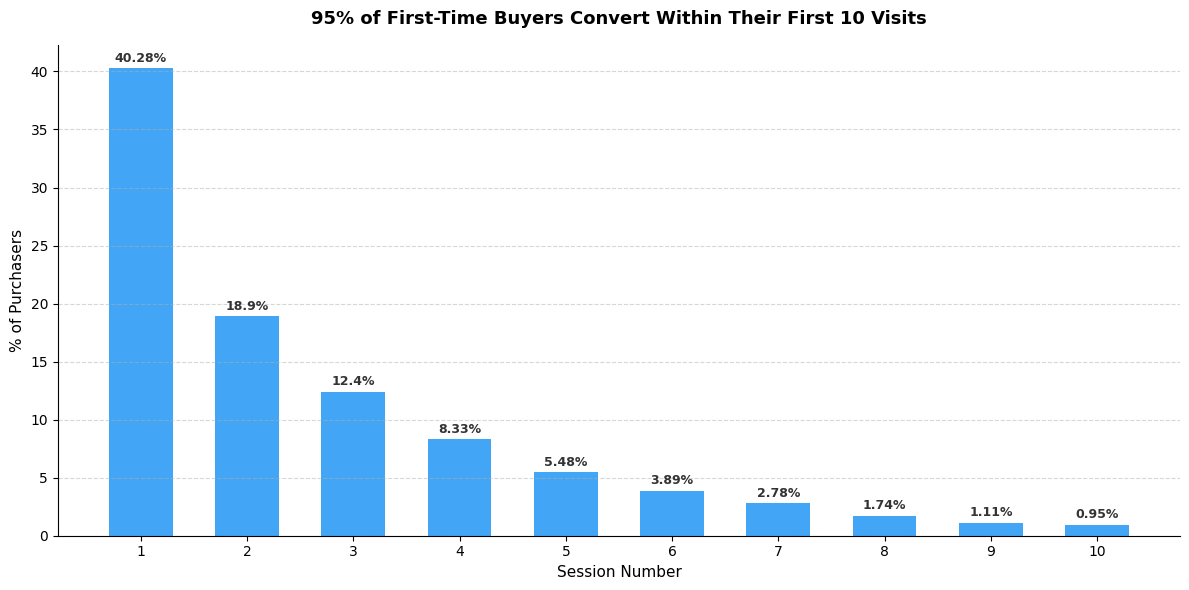

In [49]:
df_viz = df_sessions_to_purchase[df_sessions_to_purchase['session_number'] <= 10].copy()

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(df_viz['session_number'], df_viz['pct_user'], color='#42A5F5', width=0.6)

for bar, pct in zip(bars, df_viz['pct_user']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')

ax.set_title('95% of First-Time Buyers Convert Within Their First 10 Visits',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Session Number', fontsize=11)
ax.set_ylabel('% of Purchasers', fontsize=11)
ax.set_xticks(df_viz['session_number'])
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [27]:
query = f"""
SELECT DISTINCT ep.key
FROM `{dataset}.events_*`,
UNNEST(event_params) AS ep
ORDER BY ep.key
"""
client.query(query).to_dataframe()

,key
0,all_data
1,campaign
2,clean_event
3,coupon
4,currency
5,dclid
6,debug_mode
7,engaged_session_event
8,engagement_time_msec
9,entrances


**COHORT ANALYSIS**

>Only 6% of new visitors return the following week, and repeat
  purchase rate is 2-3% within 92 days

  >92 days of data is insufficient for meaningful cohort analysis
  in a low-frequency merchandise store. A minimum of 12 months
  would be needed to properly evaluate retention, repeat purchase
  behavior, and seasonal acquisition patterns.

In [28]:
query=f"""
WITH user_cohort AS(
  SELECT
    user_pseudo_id,
    DATE_TRUNC(MIN(PARSE_DATE('%Y%m%d', event_date)), WEEK) as cohort_week
  FROM `{dataset}.events_*`
  GROUP BY user_pseudo_id
),
user_activity AS (
  SELECT DISTINCT
    user_pseudo_id,
    DATE_TRUNC(PARSE_DATE('%Y%m%d',event_date),WEEK) as activity_week
  FROM `{dataset}.events_*`
)
SELECT
  c.cohort_week,
  u.activity_week,
  DATE_DIFF(u.activity_week,c.cohort_week,WEEK) AS weekgap,
  COUNT(DISTINCT c.user_pseudo_id) as user_count
FROM user_cohort c INNER JOIN user_activity u ON c.user_pseudo_id=u.user_pseudo_id
GROUP BY c.cohort_week,u.activity_week,weekgap
ORDER BY c.cohort_week,weekgap
"""
df_cohort=client.query(query).to_dataframe()
df_cohort

,cohort_week,activity_week,weekgap,user_count
0,2020-11-01,2020-11-01,0,20078
1,2020-11-01,2020-11-08,1,1267
2,2020-11-01,2020-11-15,2,693
3,2020-11-01,2020-11-22,3,453
4,2020-11-01,2020-11-29,4,455
...,...,...,...,...
100,2021-01-17,2021-01-24,1,865
101,2021-01-17,2021-01-31,2,47
102,2021-01-24,2021-01-24,0,19560
103,2021-01-24,2021-01-31,1,193


In [29]:
query=f"""
WITH user_cohort AS(
  SELECT
    user_pseudo_id,
    DATE_TRUNC(MIN(PARSE_DATE('%Y%m%d', event_date)), WEEK) as cohort_week
  FROM `{dataset}.events_*`
  GROUP BY user_pseudo_id
),
user_activity AS (
  SELECT DISTINCT
    user_pseudo_id,
    DATE_TRUNC(PARSE_DATE('%Y%m%d',event_date),WEEK) as activity_week
  FROM `{dataset}.events_*`
),
summary as (
  SELECT
    c.cohort_week,
    DATE_DIFF(u.activity_week,c.cohort_week,WEEK) AS week_gap,
    COUNT(DISTINCT c.user_pseudo_id) as user_count
  FROM user_cohort c LEFT JOIN user_activity u
  ON c.user_pseudo_id=u.user_pseudo_id
  GROUP BY c.cohort_week,week_gap
)
SELECT *,
  ROUND((user_count*100.0)/FIRST_VALUE(user_count) OVER(PARTITION BY cohort_week
    ORDER BY week_gap),2) AS retention_rate
FROM summary
"""
df_cohort=client.query(query).to_dataframe()
df_pivot=df_cohort.pivot(index='cohort_week',columns='week_gap',values='retention_rate')
df_pivot

week_gap,0,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_week,,,,,,,,,,,,,,
2020-11-01,100.0,6.31,3.45,2.26,2.27,1.92,1.27,0.59,0.37,0.64,0.52,0.41,0.41,0.02
2020-11-08,100.0,6.58,3.23,2.63,2.49,1.58,0.78,0.46,0.60,0.55,0.55,0.44,0.02,NaN
2020-11-15,100.0,5.83,3.35,2.44,1.80,0.78,0.41,0.52,0.48,0.41,0.39,0.02,NaN,NaN
2020-11-22,100.0,5.36,2.66,1.74,0.78,0.47,0.57,0.46,0.39,0.47,0.02,NaN,NaN,NaN
2020-11-29,100.0,5.51,2.29,0.84,0.64,0.65,0.59,0.38,0.47,0.03,NaN,NaN,NaN,NaN
2020-12-06,100.0,3.55,1.05,0.67,1.08,0.64,0.43,0.38,0.02,NaN,NaN,NaN,NaN,NaN
2020-12-13,100.0,2.91,0.93,1.21,0.90,0.55,0.52,0.03,NaN,NaN,NaN,NaN,NaN,NaN
2020-12-20,100.0,2.53,1.22,0.96,0.60,0.40,0.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-12-27,100.0,2.55,0.93,0.56,0.53,0.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
query=f"""
WITH user_cohort AS(
  SELECT
    user_pseudo_id,
    DATE_TRUNC(MIN(PARSE_DATE('%Y%m%d', event_date)), WEEK) as cohort_week
  FROM `{dataset}.events_*`
  WHERE event_name='purchase'
  GROUP BY user_pseudo_id
),
user_activity AS (
  SELECT DISTINCT
    user_pseudo_id,
    DATE_TRUNC(PARSE_DATE('%Y%m%d',event_date),WEEK) as activity_week
  FROM `{dataset}.events_*`
  WHERE event_name='purchase'
),
summary as (
  SELECT
    c.cohort_week,
    DATE_DIFF(u.activity_week,c.cohort_week,WEEK) AS week_gap,
    COUNT(DISTINCT c.user_pseudo_id) as user_count
  FROM user_cohort c LEFT JOIN user_activity u
  ON c.user_pseudo_id=u.user_pseudo_id
  GROUP BY c.cohort_week,week_gap
)
SELECT *,
  ROUND((user_count*100.0)/FIRST_VALUE(user_count) OVER(PARTITION BY cohort_week
    ORDER BY week_gap),2) AS retention_rate
FROM summary
"""
df_cohort=client.query(query).to_dataframe()
df_pivot=df_cohort.pivot(index='cohort_week',columns='week_gap',values='retention_rate')
df_pivot

week_gap,0,1,2,3,4,5,6,7,8,9,10,11
cohort_week,,,,,,,,,,,,
2020-11-01,100.0,2.68,1.34,1.79,0.45,1.34,0.89,0.45,0.45,0.45,NaN,NaN
2020-11-08,100.0,2.12,1.82,2.73,3.03,0.61,0.30,0.91,NaN,NaN,NaN,0.30
2020-11-15,100.0,0.87,2.62,2.91,0.87,1.16,0.29,0.29,0.58,NaN,0.58,0.29
2020-11-22,100.0,1.08,2.15,2.37,0.65,0.22,0.22,NaN,NaN,0.65,NaN,NaN
2020-11-29,100.0,3.60,1.26,1.08,0.72,0.54,0.54,0.36,0.36,NaN,NaN,NaN
2020-12-06,100.0,2.70,0.45,0.45,0.30,0.90,0.45,0.60,NaN,NaN,NaN,NaN
2020-12-13,100.0,1.72,0.38,1.34,0.38,0.38,0.76,NaN,NaN,NaN,NaN,NaN
2020-12-20,100.0,0.99,0.50,1.49,NaN,0.50,0.50,NaN,NaN,NaN,NaN,NaN
2020-12-27,100.0,0.80,0.80,1.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
query = f"""
SELECT COUNT(DISTINCT user_pseudo_id) as total,
COUNT(DISTINCT CASE WHEN event_name='purchase' THEN user_pseudo_id END) as purchasers
FROM `{dataset}.events_*`
"""
client.query(query).to_dataframe()

,total,purchasers
0,270154,4419


In [32]:
query=f"""
WITH user_cohort AS (
  SELECT
    user_pseudo_id,
    DATE_TRUNC(MIN(PARSE_DATE('%Y%m%d',event_date)),WEEK) as cohort_week
  FROM `{dataset}.events_*` GROUP BY 1
),
cohort_size AS (
  SELECT
    cohort_week,
    COUNT(user_pseudo_id) as user_count,
  FROM user_cohort
  GROUP BY cohort_week
)
SELECT
  cohort_week,
  user_count,
  ROUND(((user_count - LAG(user_count) OVER(ORDER BY cohort_week)) * 100.0 / LAG(user_count) OVER(ORDER BY cohort_week)),2) growth_rate
FROM cohort_size
ORDER BY cohort_week
"""
client.query(query).to_dataframe()

,cohort_week,user_count,growth_rate
0,2020-11-01,20078,NaN
1,2020-11-08,16232,-19.16
2,2020-11-15,17845,9.94
3,2020-11-22,19637,10.04
4,2020-11-29,21991,11.99
5,2020-12-06,28069,27.64
6,2020-12-13,25153,-10.39
7,2020-12-20,17830,-29.11
8,2020-12-27,16539,-7.24
9,2021-01-03,22774,37.70


**PRODUCT AND REVENUE ANALYSIS**

In [33]:
query=f"""
SELECT
  COUNTIF(ecommerce.transaction_id IS NULL) AS missing_ids,
  COUNT(ecommerce.transaction_id) AS total_rows_with_id,
  COUNT(DISTINCT ecommerce.transaction_id) AS unique_transactions,

  COUNT(ecommerce.total_item_quantity) AS rows_with_quantity,
  COUNT(ecommerce.purchase_revenue_in_usd) AS rows_with_revenue,

  COUNTIF(ecommerce.purchase_revenue_in_usd IS NULL AND ecommerce.total_item_quantity IS NULL) AS missing_both,
  COUNTIF(ecommerce.purchase_revenue_in_usd IS NULL AND ecommerce.total_item_quantity IS NOT NULL) AS missing_only_rev,
  COUNTIF(ecommerce.purchase_revenue_in_usd IS NOT NULL AND ecommerce.total_item_quantity IS NULL) AS missing_only_qty

FROM `{dataset}.events_*`
WHERE event_name = 'purchase'
"""
client.query(query).to_dataframe()

,missing_ids,total_rows_with_id,unique_transactions,rows_with_quantity,rows_with_revenue,missing_both,missing_only_rev,missing_only_qty
0,23,5669,4452,5242,5692,0,0,450


In [34]:
query=f"""
SELECT
  COUNT(DISTINCT user_pseudo_id) AS users_per_id,

  COUNT(DISTINCT ecommerce.purchase_revenue_in_usd) AS revenues_per_id,

  ecommerce.transaction_id
FROM `{dataset}.events_*`
WHERE event_name = 'purchase'
  AND ecommerce.transaction_id IS NOT NULL
GROUP BY ecommerce.transaction_id
HAVING COUNT(ecommerce.transaction_id) > 1
LIMIT 10;
"""
client.query(query).to_dataframe()

,users_per_id,revenues_per_id,transaction_id
0,767,149,(not set)
1,2,2,748583
2,1,1,715527
3,1,1,22807
4,1,1,179828
5,1,1,179007
6,1,1,351216
7,1,1,457343
8,1,1,968768
9,1,1,50181


In [35]:
view_query = f"""
CREATE OR REPLACE VIEW `{project_id}.ga4_analysis.clean_purchases` AS
SELECT *
FROM `{dataset}.events_*`
WHERE event_name = 'purchase'
AND ecommerce.transaction_id IS NOT NULL
AND ecommerce.purchase_revenue_in_usd IS NOT NULL
AND ecommerce.total_item_quantity IS NOT NULL
QUALIFY ROW_NUMBER() OVER(PARTITION BY  ecommerce.transaction_id ORDER BY event_timestamp) = 1
"""
client.query(view_query).result()

In [36]:
query=f"""
SELECT
  COUNTIF(ecommerce.transaction_id IS NULL) AS missing_ids,
  COUNT(ecommerce.transaction_id) AS total_rows_with_id,
  COUNT(DISTINCT ecommerce.transaction_id) AS unique_transactions,

  COUNT(ecommerce.total_item_quantity) AS rows_with_quantity,
  COUNT(ecommerce.purchase_revenue_in_usd) AS rows_with_revenue,

  COUNTIF(ecommerce.purchase_revenue_in_usd IS NULL AND ecommerce.total_item_quantity IS NULL) AS missing_both,
  COUNTIF(ecommerce.purchase_revenue_in_usd IS NULL AND ecommerce.total_item_quantity IS NOT NULL) AS missing_only_rev,
  COUNTIF(ecommerce.purchase_revenue_in_usd IS NOT NULL AND ecommerce.total_item_quantity IS NULL) AS missing_only_qty

FROM `{project_id}.ga4_analysis.clean_purchases`
"""
client.query(query).to_dataframe()

,missing_ids,total_rows_with_id,unique_transactions,rows_with_quantity,rows_with_revenue,missing_both,missing_only_rev,missing_only_qty
0,0,4452,4452,4452,4452,0,0,0


In [37]:
query=f"""
SELECT
  COUNT(DISTINCT ecommerce.transaction_id) AS total_transactions,
  COUNT(DISTINCT user_pseudo_id) AS total_users,
  SUM(ecommerce.purchase_revenue_in_usd) AS total_rev,
  ROUND(AVG(ecommerce.purchase_revenue_in_usd),2) AS avg_order_value
FROM `{project_id}.ga4_analysis.clean_purchases`
"""
client.query(query).to_dataframe()

,total_transactions,total_users,total_rev,avg_order_value
0,4452,3703,307707.0,69.12


 >Top 5 revenue products are all apparel items, with hoodies and
  sweatshirts leading — suggesting cold weather seasonal demand
  (data is Nov-Jan)

In [38]:
query=f"""
SELECT
  item_name,
  SUM(item_revenue) as total_rev,
  SUM(quantity) as units_sold,
  COUNT(DISTINCT user_pseudo_id) as total_users,
FROM `{project_id}.ga4_analysis.clean_purchases`,
UNNEST(items)
GROUP BY item_name
ORDER BY SUM(item_revenue) DESC
LIMIT 5
"""
client.query(query).to_dataframe()

,item_name,total_rev,units_sold,total_users
0,Google Zip Hoodie F/C,10488.0,208,179
1,Google Crewneck Sweatshirt Navy,9878.0,217,186
2,Google Badge Heavyweight Pullover Black,8444.0,175,144
3,Google Men's Tech Fleece Grey,7886.0,107,83
4,Super G Unisex Joggers,7826.0,252,184


>Apparel drives 47% of total revenue and dominates both units sold
  and unique buyers — it's the core product line of this store

In [39]:
query=f"""
SELECT
 item_category,
 SUM(item_revenue) as revenue,
 SUM(quantity) as units_sold,
 COUNT(DISTINCT user_pseudo_id) as total_users
FROM `{project_id}.ga4_analysis.clean_purchases`,
UNNEST(items)
GROUP BY item_category
ORDER BY SUM(item_revenue) DESC
LIMIT 5
"""
client.query(query).to_dataframe()

,item_category,revenue,units_sold,total_users
0,Apparel,144486.0,4594,2229
1,New,22047.0,1817,821
2,Bags,21238.0,953,459
3,Campus Collection,16524.0,1839,661
4,Accessories,15124.0,1686,702


In [40]:
query = f"""
SELECT
  MIN(ecommerce.purchase_revenue_in_usd) AS min_order,
  MAX(ecommerce.purchase_revenue_in_usd) AS max_order,
  AVG(ecommerce.purchase_revenue_in_usd) AS avg_order,
  STDDEV(ecommerce.purchase_revenue_in_usd) AS std_order,
  APPROX_QUANTILES(ecommerce.purchase_revenue_in_usd, 100)[OFFSET(25)] AS p25,
  APPROX_QUANTILES(ecommerce.purchase_revenue_in_usd, 100)[OFFSET(50)] AS p50,
  APPROX_QUANTILES(ecommerce.purchase_revenue_in_usd, 100)[OFFSET(75)] AS p75,
  APPROX_QUANTILES(ecommerce.purchase_revenue_in_usd, 100)[OFFSET(95)] AS p95
FROM `{project_id}.ga4_analysis.clean_purchases`
"""
client.query(query).to_dataframe()

,min_order,max_order,avg_order,std_order,p25,p50,p75,p95
0,1.0,1530.0,69.116577,79.545943,27.0,48.0,84.0,185.0


>RFM segmentation identifies 301 Champions (8.1%) and 260 At-Risk
  customers (7%, ~$159 avg spend, 65+ days inactive) as the highest
  priority segments — At-Risk customers are nearly as valuable as
  Champions but going quiet. With only 92 days of data, these labels
  reflect a snapshot — frequency scores in particular would likely
  shift with a longer observation window.

In [48]:
query=f"""
WITH  customer_metric AS (
  SELECT
    user_pseudo_id,
    DATE_DIFF((SELECT MAX(PARSE_DATE('%Y%m%d',event_date)) FROM `{project_id}.ga4_analysis.clean_purchases`),MAX(PARSE_DATE('%Y%m%d',event_date)), DAY) as recency_days,
    COUNT(DISTINCT ecommerce.transaction_id) as transactions,
    SUM(ecommerce.purchase_revenue_in_usd) as revenue
  FROM `{project_id}.ga4_analysis.clean_purchases`
  GROUP BY user_pseudo_id
),
rfm_score AS (
  SELECT
    user_pseudo_id,
    recency_days,
    transactions,
    revenue,
    NTILE(5) OVER(ORDER BY recency_days DESC, user_pseudo_id ASC) as r_score,
    NTILE(5) OVER(ORDER BY transactions ASC, user_pseudo_id ASC) AS f_score,
    NTILE(5) OVER(ORDER BY revenue ASC, user_pseudo_id ASC) AS m_score
  FROM customer_metric
),
rfm_label AS (
  SELECT *,
    CASE
      WHEN r_score>=4 AND f_score>=4 AND m_score>=4 THEN 'Champion'
      WHEN r_score>=4 AND (f_score BETWEEN 2 AND 3) AND m_score>=2 THEN 'Potential Loyalist'
      WHEN r_score>=3 AND f_score>=3 AND m_score>=3 THEN 'Loyal'
      WHEN r_score<=2 AND f_score>=4 AND m_score>=4 THEN 'At-Risk'
      WHEN r_score<=2 AND f_score<=2 AND m_score<=2 THEN 'Lost'
      ELSE 'Normal'
    END AS label
  FROM rfm_score
)
SELECT
  label,
  COUNT(user_pseudo_id) as users,
  ROUND(COUNT(user_pseudo_id) * 100.0 / SUM(COUNT(user_pseudo_id)) OVER(), 1) AS pct_users,
  AVG(transactions) as avg_trans,
  AVG(revenue) as avg_rev,
  ROUND(AVG(recency_days),1) as avg_recency,
  SUM(revenue) as total_amount
FROM rfm_label
GROUP BY label ORDER BY users DESC
"""
df_rfm =client.query(query).to_dataframe()
df_rfm

,label,users,pct_users,avg_trans,avg_rev,avg_recency,total_amount
0,Normal,2018,54.5,1.033697,62.856789,49.2,126845.0
1,Potential Loyalist,434,11.7,1.000000,80.474654,26.0,34926.0
2,Loyal,399,10.8,1.521303,117.117794,43.8,46730.0
3,Champion,301,8.1,1.990033,167.534884,26.3,50428.0
4,Lost,291,7.9,1.000000,25.872852,65.8,7529.0
5,At-Risk,260,7.0,1.673077,158.650000,65.2,41249.0


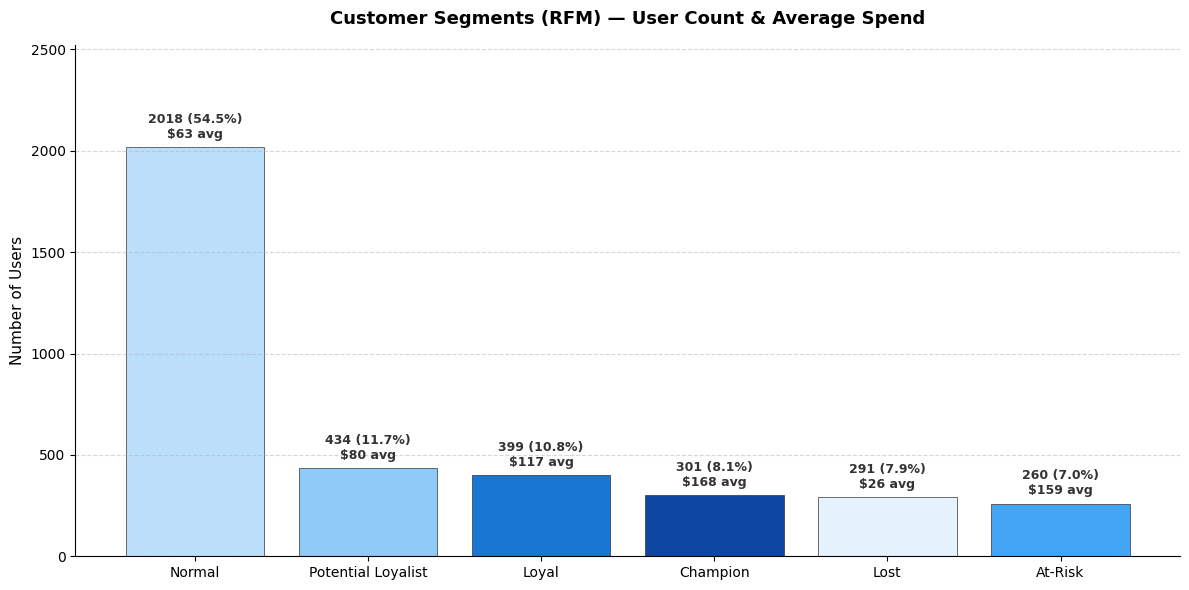

In [47]:
fig, ax = plt.subplots(figsize=(12, 6))

df_rfm = df_rfm.sort_values('users', ascending=False)

colors = {'Champion': '#0D47A1', 'Loyal': '#1976D2', 'At-Risk': '#42A5F5',
          'Potential Loyalist': '#90CAF9', 'Normal': '#BBDEFB', 'Lost': '#E3F2FD'}
bar_colors = [colors.get(label, '#90CAF9') for label in df_rfm['label']]

bars = ax.bar(df_rfm['label'], df_rfm['users'], color=bar_colors, edgecolor='#333333', linewidth=0.5)

for bar, users, pct, rev in zip(bars, df_rfm['users'], df_rfm['pct_users'], df_rfm['avg_rev']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{users} ({pct}%)\n${rev:.0f} avg', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#333333')

ax.set_title('Customer Segments (RFM) — User Count & Average Spend',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Number of Users', fontsize=11)
ax.set_ylim(0, max(df_rfm['users']) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**SEARCH ANALYSIS**

In [43]:
query=f"""
SELECT
  COUNT(*) AS cnt,
  (SELECT value.string_value FROM UNNEST(event_params) WHERE key='search_term') as search_val,
  (SELECT value.int_value FROM UNNEST(event_params) WHERE key='search_term') as search,
FROM `{dataset}.events_*`
WHERE event_name='view_search_results'
GROUP BY search_val,search ORDER BY cnt DESC
"""
client.query(query).to_dataframe()

,cnt,search_val,search
0,26172,<obfuscated>,<NA>


>Users who search convert at 6.1% vs 1.4% for non-searchers —
  4.4x higher. Search is the strongest purchase intent signal on site.

In [44]:
query=f"""
WITH customer_behaviour AS (
  SELECT
    user_pseudo_id,
    MAX(CASE WHEN event_name='view_search_results' THEN 1 ELSE 0 END) as has_searched,
    MAX(CASE WHEN event_name='purchase' THEN 1 ELSE 0 END) as has_purchased
  FROM `{dataset}.events_*`
  GROUP BY user_pseudo_id
)
SELECT
  CASE WHEN has_searched=1 THEN 'Searched' ELSE 'Not searched' END AS user_group,
  COUNT(user_pseudo_id) as total_users,
  SUM(has_purchased) as total_buyers,
  ROUND(SAFE_DIVIDE(SUM(has_purchased), COUNT(user_pseudo_id)) * 100, 1)
FROM customer_behaviour
GROUP BY has_searched
"""
client.query(query).to_dataframe()

,user_group,total_users,total_buyers,f0_
0,Not searched,255705,3532,1.4
1,Searched,14449,887,6.1


**PROMOTION ANALYSIS**

>Users who click promotions convert at 6.5% vs 1.5% for non-clickers
  — 4.3x higher, though this may reflect high-intent users rather
  than promotion impact itself.

In [45]:
query=f"""
WITH customer_behaviour AS (
  SELECT
    user_pseudo_id,
    MAX(CASE WHEN event_name='select_promotion' THEN 1 ELSE 0 END) as has_promotion,
    MAX(CASE WHEN event_name='purchase' THEN  1 ELSE 0 END) as has_purchase
  FROM `{dataset}.events_*`
  GROUP BY user_pseudo_id
)
SELECT
  CASE WHEN has_promotion=1 THEN 'promotion' ELSE 'No promotion' END as user_group,
  COUNT(user_pseudo_id) as total_users,
  SUM(has_purchase) as total_buyers,
  ROUND(SAFE_DIVIDE(SUM(has_purchase),COUNT(user_pseudo_id))*100,1) as rate
FROM customer_behaviour
GROUP BY has_promotion
"""
client.query(query).to_dataframe()

,user_group,total_users,total_buyers,rate
0,No promotion,261990,3890,1.5
1,promotion,8164,529,6.5
